In [1]:
import geopandas as gpd
from shapely.ops import snap
import networkx as nx
from shapely.geometry import Point
import numpy as np

In [2]:
watershed = gpd.read_file("GIS/WATERSHEDS_CLIPPED.geojson")
watershed = watershed[watershed['NAME'] == 'Popes Head Creek']
watershed = watershed.to_crs('EPSG:26918')

In [3]:
s14 = gpd.read_file('stormnet/14.geojson')
s14 = s14.to_crs(watershed.crs).clip(watershed)

<Axes: >

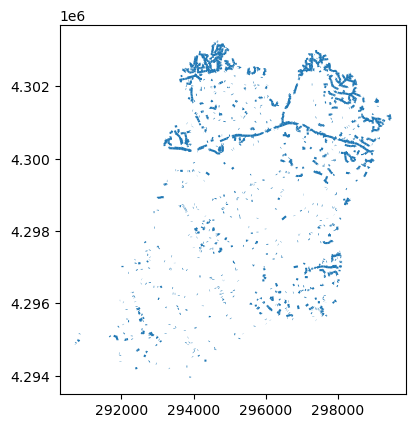

In [4]:
s14['geometry'] = s14.geometry.apply(lambda x: snap(x, s14.union_all(), 1))
s14.plot()

In [5]:
G = nx.DiGraph()
for idx, row in s14.iterrows():
    if row.geometry.geom_type != 'LineString':
        continue
    line = row.geometry
    
    start_point = Point(line.coords[0])
    end_point   = Point(line.coords[-1])
    
    # Convert coordinate tuples to node IDs
    start_id = (round(start_point.x, 3), round(start_point.y, 3))
    end_id   = (round(end_point.x, 3),   round(end_point.y, 3))

    # Add nodes
    G.add_node(start_id, x=start_point.x, y=start_point.y)
    G.add_node(end_id,   x=end_point.x,   y=end_point.y)

    # Add edge with attributes from the row
    G.add_edge(
        start_id,
        end_id,
        pipe_id=row["STORMNET_ID"],
        length=row["ASSETLENGTH"],
        slope=row["SLOPE"],
        diameter=row["HEIGHT_DIA"],
        material=row["MATERIAL"],
        geometry=line
    )


In [6]:
import pickle
with open('pipe_graph.pickle', 'wb') as f:
    pickle.dump(G, f)

In [64]:
node_geoms = []
node_ids = []

for n, data in G.nodes(data=True):
    node_ids.append(n)
    node_geoms.append(Point(data["x"], data["y"]))

nodes_gdf = gpd.GeoDataFrame(
    {"node_id": node_ids},
    geometry=node_geoms,
    crs=s14.crs
)


In [62]:
outfalls = s13[(s13.TYPE == 'Outfall') | (s13.TYPE == 'MS4 OUTFALL')]

In [95]:
drainage_sources = ['Inlet', 'Infall']
is_source = [s13['TYPE'].str.contains(source) for source in drainage_sources]
is_source = np.logical_or(*is_source)
is_source = np.where(is_source.isna(), False, is_source)
drainage = s13[is_source]

<Axes: >

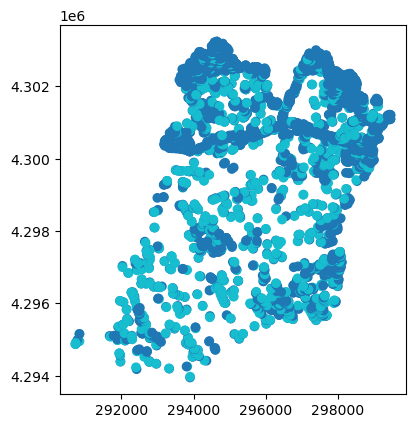

In [85]:
nodes_gdf.plot(column='is_outfall')

In [111]:
node_id = nodes_gdf[nodes_gdf.is_inlet & nodes_gdf.is_outfall].iloc[0].node_id

In [118]:
G.in_edges(node_id, data=True)

InEdgeDataView([((295031.889, 4295573.151), (295023.931, 4295584.029), {'pipe_id': 'STML0763162673', 'length': 0.0, 'slope': 0.0, 'diameter': nan, 'material': 'XXX', 'geometry': <LINESTRING (295031.889 4295573.151, 295029.606 4295576.272, 295026.86 42955...>})])

In [123]:
possible_matches_idx

[array([0]), array([2486])]

In [96]:
node_sindex = nodes_gdf.sindex

nearest_nodes = []
distances = []

for idx, of in drainage.iterrows():
    possible_matches_idx = list(node_sindex.nearest(of.geometry, 1))
    candidates = nodes_gdf.iloc[np.concatenate(possible_matches_idx)].copy()
    candidates["dist"] = candidates.geometry.distance(of.geometry)
    nearest = candidates.sort_values("dist").iloc[0]
    nearest_nodes.append(nearest["node_id"])
    distances.append(nearest["dist"])

drainage["nearest_node"] = nearest_nodes
drainage["distance_to_node"] = distances
nodes_gdf["is_inlet"] = nodes_gdf["node_id"].isin(nearest_nodes)

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [119]:
node_sindex = nodes_gdf.sindex

nearest_nodes = []
distances = []

for idx, of in outfalls.iterrows():
    possible_matches_idx = list(node_sindex.nearest(of.geometry, 1))
    candidates = nodes_gdf.iloc[np.concatenate(possible_matches_idx)].copy()
    candidates["dist"] = candidates.geometry.distance(of.geometry)
    nearest = candidates.sort_values("dist").iloc[0]
    nearest_nodes.append(nearest["node_id"])
    distances.append(nearest["dist"])

outfalls["nearest_node"] = nearest_nodes
outfalls["distance_to_node"] = distances
nodes_gdf["is_outfall"] = nodes_gdf["node_id"].isin(nearest_nodes)

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

